In [18]:
# Mossesse Amoozeshi

In [19]:
import os

pwd = os.getcwd()
if pwd.endswith("notebooks"):
    os.chdir("..")

In [20]:
from scm import SCM
import numpy as np
import matplotlib.pyplot as plt

In [21]:
np.random.seed(42)
s = SCM()

In [22]:
s.add_variable("u", [], lambda _, n: np.random.normal(0, 1, n))
s.add_variable(
    "x", ["u"], 
    lambda pars, n: (7 * pars["u"] + np.random.normal(0, 1, n) > 0).astype(int)
)
s.add_variable(
    "y", ["x", "u"], 
    lambda pars, n: 3 * pars["x"] + 2 * pars["u"] + np.random.normal(0, 1, n)
)

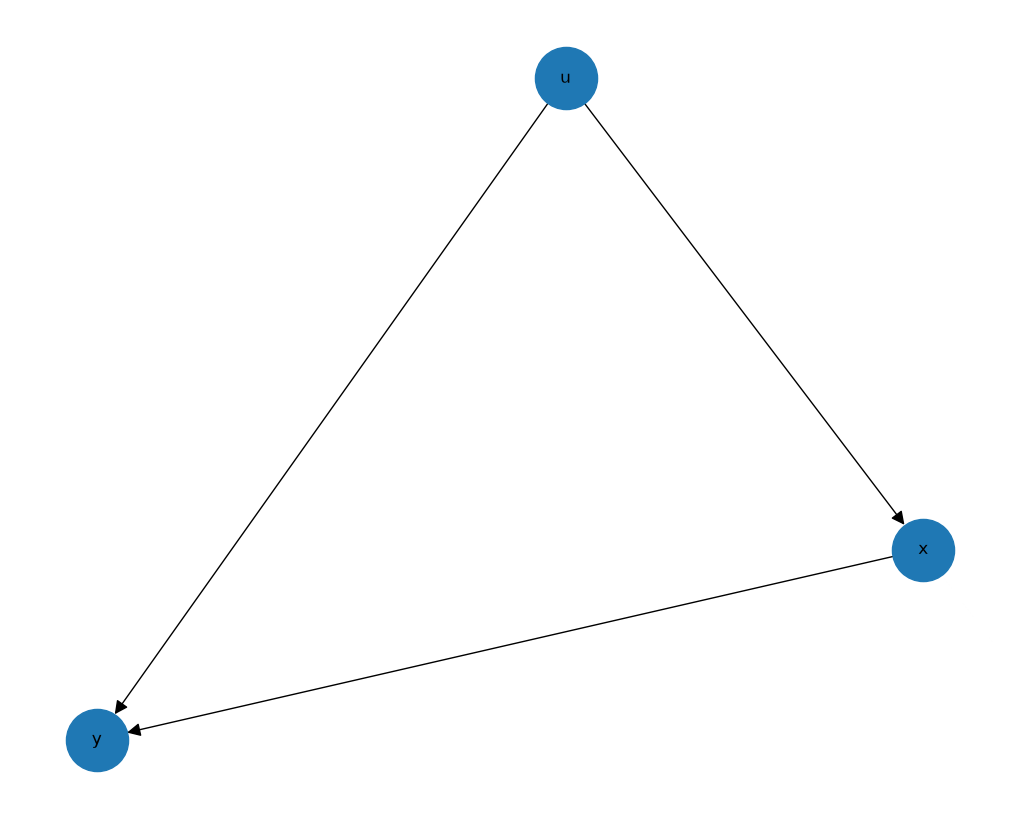

In [23]:
s.plot_graph()
plt.savefig("../report/images/causal_graph.png", dpi=300)

In [24]:
samples = s.sample(10_000)
e1 = samples[samples["x"] == 1]["y"].mean()
e0 = samples[samples["x"] == 0]["y"].mean()
print(e1 - e0)

6.22758964557649


In [25]:
interv_scm = s.do_operator({"x": 1})
interv_samples = interv_scm.sample(10_000)
e1 = interv_samples["y"].mean()
interv_scm = s.do_operator({"x": 0})
interv_samples = interv_scm.sample(10_000)
e0 = interv_samples["y"].mean()
print(e1 - e0)

2.9780376353445415
